###### 132_2_light_review_lcm_datetime_answer.ipynb

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.max_columns", None)
plt.rcParams["font.family"] = "Meiryo"

In [3]:
#cell 3
df = pd.read_csv("dataset/lcm_occurrence_datetime_real.csv",
                 encoding="utf-8-sig")
df

,defect_id,site,customer,model,defect_category,defect_qty,occ_at,cm_status
0,D001,SUS,Honda,J69P,Buck-IC,3,2026-07-01 09:15:00+09:00,回答済
1,D002,WSE,Honda,310D,Coil,1,2026-07-01 14:30:00+09:00,回答済
2,D003,GSE,Mitsubishi,310D,NTF,1,2026-07-02 23:10:00+09:00,回答済
3,D004,MELMB,Honda,J69P,Buck-IC,2,2026/07/03 00:40,調査中
4,D005,SUS,Mitsubishi,310D,Coil,4,2026/07/04 08:20,回答済
5,D006,WSE,Honda,J69P,NTF,1,2026-07-04 18:45,回答済
6,D007,GSE,Honda,310D,Buck-IC,5,2026-07-05 21:30,回答済
7,D008,MELMB,Mitsubishi,J69P,Coil,2,2026-07-06 11:10:00+09:00,調査中
8,D009,SUS,Honda,310D,Coil,3,2026-08-01 07:55:00+09:00,回答済
9,D010,WSE,Mitsubishi,310D,Buck-IC,2,2026-08-02 15:30:00+09:00,回答済


In [4]:
df.dtypes

defect_id          object
site               object
customer           object
model              object
defect_category    object
defect_qty         object
occ_at             object
cm_status          object
dtype: object

In [5]:
df["defect_qty_num"] = pd.to_numeric(
    df["defect_qty"],
    errors="coerce",
)

df[
    [
        "defect_id",
        "defect_qty",
        "defect_qty_num",
    ]
]

,defect_id,defect_qty,defect_qty_num
0,D001,3,3.0
1,D002,1,1.0
2,D003,1,1.0
3,D004,2,2.0
4,D005,4,4.0
5,D006,1,1.0
6,D007,5,5.0
7,D008,2,2.0
8,D009,3,3.0
9,D010,2,2.0


In [7]:
df["occ_at_clean"] = (
    df["occ_at"]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\+09:00$",
        "",
        regex=True,
    )
)
df[
    [
        "defect_id",
        "occ_at",
        "occ_at_clean",
    ]
]

,defect_id,occ_at,occ_at_clean
0,D001,2026-07-01 09:15:00+09:00,2026-07-01 09:15:00
1,D002,2026-07-01 14:30:00+09:00,2026-07-01 14:30:00
2,D003,2026-07-02 23:10:00+09:00,2026-07-02 23:10:00
3,D004,2026/07/03 00:40,2026/07/03 00:40
4,D005,2026/07/04 08:20,2026/07/04 08:20
5,D006,2026-07-04 18:45,2026-07-04 18:45
6,D007,2026-07-05 21:30,2026-07-05 21:30
7,D008,2026-07-06 11:10:00+09:00,2026-07-06 11:10:00
8,D009,2026-08-01 07:55:00+09:00,2026-08-01 07:55:00
9,D010,2026-08-02 15:30:00+09:00,2026-08-02 15:30:00


In [8]:
#cell 7
df["occ_at"] = pd.to_datetime(
    df["occ_at_clean"],
    format="mixed",
    errors="coerce",
)

df[
    [
        "defect_id",
        "occ_at_clean",
        "occ_at",
    ]
]

,defect_id,occ_at_clean,occ_at
0,D001,2026-07-01 09:15:00,2026-07-01 09:15:00
1,D002,2026-07-01 14:30:00,2026-07-01 14:30:00
2,D003,2026-07-02 23:10:00,2026-07-02 23:10:00
3,D004,2026/07/03 00:40,2026-07-03 00:40:00
4,D005,2026/07/04 08:20,2026-07-04 08:20:00
5,D006,2026-07-04 18:45,2026-07-04 18:45:00
6,D007,2026-07-05 21:30,2026-07-05 21:30:00
7,D008,2026-07-06 11:10:00,2026-07-06 11:10:00
8,D009,2026-08-01 07:55:00,2026-08-01 07:55:00
9,D010,2026-08-02 15:30:00,2026-08-02 15:30:00


In [9]:
df.dtypes

defect_id                  object
site                       object
customer                   object
model                      object
defect_category            object
defect_qty                 object
occ_at             datetime64[ns]
cm_status                  object
defect_qty_num            float64
occ_at_clean       string[python]
dtype: object

In [11]:
df_invalid_date = df[
    df["occ_at"].isna()
].copy()

df_invalid_date[
    [
        "defect_id",
        "site",
        "customer",
        "model",
        "occ_at_clean",
        "occ_at",
        "cm_status",
    ]
]

,defect_id,site,customer,model,occ_at_clean,occ_at,cm_status
16,D017,WSE,Mitsubishi,310D,<NA>,NaT,未回答
17,D018,GSE,Honda,J69P,2026-13-01 10:00:00,NaT,調査中


In [13]:
df_invalid_qty = df[
    df["defect_qty_num"].isna()
].copy()

In [14]:
df_invalid_qty[
    [
        "defect_id",
        "site",
        "customer",
        "model",
        "defect_qty",
        "defect_qty_num",
        "occ_at",
    ]
]

,defect_id,site,customer,model,defect_qty,defect_qty_num,occ_at
15,D016,SUS,Honda,J69P,未入力,NaN,2026-08-08 09:00:00


In [15]:
df_work = df[
    df["occ_at"].notna()
].copy()
df_work

,defect_id,site,customer,model,defect_category,defect_qty,occ_at,cm_status,defect_qty_num,occ_at_clean
0,D001,SUS,Honda,J69P,Buck-IC,3,2026-07-01 09:15:00,回答済,3.0,2026-07-01 09:15:00
1,D002,WSE,Honda,310D,Coil,1,2026-07-01 14:30:00,回答済,1.0,2026-07-01 14:30:00
2,D003,GSE,Mitsubishi,310D,NTF,1,2026-07-02 23:10:00,回答済,1.0,2026-07-02 23:10:00
3,D004,MELMB,Honda,J69P,Buck-IC,2,2026-07-03 00:40:00,調査中,2.0,2026/07/03 00:40
4,D005,SUS,Mitsubishi,310D,Coil,4,2026-07-04 08:20:00,回答済,4.0,2026/07/04 08:20
5,D006,WSE,Honda,J69P,NTF,1,2026-07-04 18:45:00,回答済,1.0,2026-07-04 18:45
6,D007,GSE,Honda,310D,Buck-IC,5,2026-07-05 21:30:00,回答済,5.0,2026-07-05 21:30
7,D008,MELMB,Mitsubishi,J69P,Coil,2,2026-07-06 11:10:00,調査中,2.0,2026-07-06 11:10:00
8,D009,SUS,Honda,310D,Coil,3,2026-08-01 07:55:00,回答済,3.0,2026-08-01 07:55:00
9,D010,WSE,Mitsubishi,310D,Buck-IC,2,2026-08-02 15:30:00,回答済,2.0,2026-08-02 15:30:00


In [16]:
df_work["defect_qty_calc"] = (
    df_work["defect_qty_num"]
    .fillna(0)
    .astype(int)
)

In [17]:
df_work[
    [
        "defect_id",
        "defect_qty",
        "defect_qty_num",
        "defect_qty_calc",
    ]
]

,defect_id,defect_qty,defect_qty_num,defect_qty_calc
0,D001,3,3.0,3
1,D002,1,1.0,1
2,D003,1,1.0,1
3,D004,2,2.0,2
4,D005,4,4.0,4
5,D006,1,1.0,1
6,D007,5,5.0,5
7,D008,2,2.0,2
8,D009,3,3.0,3
9,D010,2,2.0,2


In [18]:
#cell 13

df_work["occ_date"] = df_work["occ_at"].dt.date

df_work[
    [
        "defect_id",
        "occ_at",
        "occ_date",
    ]
]

,defect_id,occ_at,occ_date
0,D001,2026-07-01 09:15:00,2026-07-01
1,D002,2026-07-01 14:30:00,2026-07-01
2,D003,2026-07-02 23:10:00,2026-07-02
3,D004,2026-07-03 00:40:00,2026-07-03
4,D005,2026-07-04 08:20:00,2026-07-04
5,D006,2026-07-04 18:45:00,2026-07-04
6,D007,2026-07-05 21:30:00,2026-07-05
7,D008,2026-07-06 11:10:00,2026-07-06
8,D009,2026-08-01 07:55:00,2026-08-01
9,D010,2026-08-02 15:30:00,2026-08-02


In [19]:
weekday_map = {
    0: "月曜日",
    1: "火曜日",
    2: "水曜日",
    3: "木曜日",
    4: "金曜日",
    5: "土曜日",
    6: "日曜日"
}

df_work["occ_weekday"] = (
    df_work["occ_at"]
    .dt.dayofweek
    .map(weekday_map)
)

df_work[
    [
        "defect_id",
        "occ_at",
        "occ_weekday",
    ]
]

,defect_id,occ_at,occ_weekday
0,D001,2026-07-01 09:15:00,水曜日
1,D002,2026-07-01 14:30:00,水曜日
2,D003,2026-07-02 23:10:00,木曜日
3,D004,2026-07-03 00:40:00,金曜日
4,D005,2026-07-04 08:20:00,土曜日
5,D006,2026-07-04 18:45:00,土曜日
6,D007,2026-07-05 21:30:00,日曜日
7,D008,2026-07-06 11:10:00,月曜日
8,D009,2026-08-01 07:55:00,土曜日
9,D010,2026-08-02 15:30:00,日曜日


In [21]:
df_work["occ_month"] = df_work["occ_at"].dt.strftime("%Y-%m")

df_work[
    [
        "defect_id",
        "occ_at",
        "occ_month",
    ]
]


,defect_id,occ_at,occ_month
0,D001,2026-07-01 09:15:00,2026-07
1,D002,2026-07-01 14:30:00,2026-07
2,D003,2026-07-02 23:10:00,2026-07
3,D004,2026-07-03 00:40:00,2026-07
4,D005,2026-07-04 08:20:00,2026-07
5,D006,2026-07-04 18:45:00,2026-07
6,D007,2026-07-05 21:30:00,2026-07
7,D008,2026-07-06 11:10:00,2026-07
8,D009,2026-08-01 07:55:00,2026-08
9,D010,2026-08-02 15:30:00,2026-08


In [22]:
df_work["occ_hour"] = df_work["occ_at"].dt.hour

df_work[
    [
        "defect_id",
        "occ_at",
        "occ_hour",
    ]
]

,defect_id,occ_at,occ_hour
0,D001,2026-07-01 09:15:00,9
1,D002,2026-07-01 14:30:00,14
2,D003,2026-07-02 23:10:00,23
3,D004,2026-07-03 00:40:00,0
4,D005,2026-07-04 08:20:00,8
5,D006,2026-07-04 18:45:00,18
6,D007,2026-07-05 21:30:00,21
7,D008,2026-07-06 11:10:00,11
8,D009,2026-08-01 07:55:00,7
9,D010,2026-08-02 15:30:00,15


In [26]:
df_work["occ_time_zone"] = ""

df_work.loc[
    df_work["occ_hour"].between(0, 5),
    "occ_time_zone"
] = "深夜"

df_work.loc[
    df_work["occ_hour"].between(6, 11),
    "occ_time_zone"
] = "午前"

df_work.loc[
    df_work["occ_hour"].between(12, 17),
    "occ_time_zone"
] = "午後"

df_work.loc[
    df_work["occ_hour"].between(18, 23),
    "occ_time_zone"
] = "夜間"

df_work[
    [
        "defect_id",
        "occ_hour",
        "occ_time_zone",
    ]
]

,defect_id,occ_hour,occ_time_zone
0,D001,9,午前
1,D002,14,午後
2,D003,23,夜間
3,D004,0,深夜
4,D005,8,午前
5,D006,18,夜間
6,D007,21,夜間
7,D008,11,午前
8,D009,7,午前
9,D010,15,午後


In [27]:
df_work[
    [
        "defect_id",
        "site",
        "customer",
        "model",
        "defect_category",
        "defect_qty",
        "defect_qty_calc",
        "occ_at",
        "occ_date",
        "occ_weekday",
        "occ_month",
        "occ_hour",
        "occ_time_zone",
        "cm_status",
    ]
]

,defect_id,site,customer,model,defect_category,defect_qty,defect_qty_calc,occ_at,occ_date,occ_weekday,occ_month,occ_hour,occ_time_zone,cm_status
0,D001,SUS,Honda,J69P,Buck-IC,3,3,2026-07-01 09:15:00,2026-07-01,水曜日,2026-07,9,午前,回答済
1,D002,WSE,Honda,310D,Coil,1,1,2026-07-01 14:30:00,2026-07-01,水曜日,2026-07,14,午後,回答済
2,D003,GSE,Mitsubishi,310D,NTF,1,1,2026-07-02 23:10:00,2026-07-02,木曜日,2026-07,23,夜間,回答済
3,D004,MELMB,Honda,J69P,Buck-IC,2,2,2026-07-03 00:40:00,2026-07-03,金曜日,2026-07,0,深夜,調査中
4,D005,SUS,Mitsubishi,310D,Coil,4,4,2026-07-04 08:20:00,2026-07-04,土曜日,2026-07,8,午前,回答済
5,D006,WSE,Honda,J69P,NTF,1,1,2026-07-04 18:45:00,2026-07-04,土曜日,2026-07,18,夜間,回答済
6,D007,GSE,Honda,310D,Buck-IC,5,5,2026-07-05 21:30:00,2026-07-05,日曜日,2026-07,21,夜間,回答済
7,D008,MELMB,Mitsubishi,J69P,Coil,2,2,2026-07-06 11:10:00,2026-07-06,月曜日,2026-07,11,午前,調査中
8,D009,SUS,Honda,310D,Coil,3,3,2026-08-01 07:55:00,2026-08-01,土曜日,2026-08,7,午前,回答済
9,D010,WSE,Mitsubishi,310D,Buck-IC,2,2,2026-08-02 15:30:00,2026-08-02,日曜日,2026-08,15,午後,回答済


In [28]:
df_weekday_summary = df_work.groupby(
    "occ_weekday",
    as_index=False,
).agg(
    defect_count=("defect_id", "count"),
    defect_qty_sum=("defect_qty_calc", "sum"),
)
df_weekday_summary

,occ_weekday,defect_count,defect_qty_sum
0,土曜日,4,8
1,日曜日,2,7
2,月曜日,2,3
3,木曜日,2,5
4,水曜日,3,6
5,火曜日,1,1
6,金曜日,2,3


In [30]:
#cell 20
weekday_order = [
    "月曜日",
    "火曜日",
    "水曜日",
    "木曜日",
    "金曜日",
    "土曜日",
    "日曜日"
]

df_weekday_summary["weekday_order"] = pd.Categorical(
    df_weekday_summary["occ_weekday"],
    categories=weekday_order,
    ordered=True,
)

df_weekday_summary = df_weekday_summary.sort_values(
    "weekday_order",
).drop(
    columns="weekday_order",
).reset_index(
    drop=True,
)

df_weekday_summary

,occ_weekday,defect_count,defect_qty_sum
0,月曜日,2,3
1,火曜日,1,1
2,水曜日,3,6
3,木曜日,2,5
4,金曜日,2,3
5,土曜日,4,8
6,日曜日,2,7


In [31]:
#cell 21
df_time_zone_summary = df_work.groupby(
    "occ_time_zone",
    as_index=False,
).agg(
    defect_count=("defect_id", "count"),
    defect_qty_sum=("defect_qty_calc", "sum"),
)

df_time_zone_summary

,occ_time_zone,defect_count,defect_qty_sum
0,午前,6,13
1,午後,3,5
2,夜間,5,12
3,深夜,2,3


In [32]:
#cell 22
time_zone_order = [
    "深夜",
    "午前",
    "午後",
    "夜間",
]

df_time_zone_summary["time_zone_order"] = pd.Categorical(
    df_time_zone_summary["occ_time_zone"],
    categories=time_zone_order,
    ordered=True,
)

df_time_zone_summary

,occ_time_zone,defect_count,defect_qty_sum,time_zone_order
0,午前,6,13,午前
1,午後,3,5,午後
2,夜間,5,12,夜間
3,深夜,2,3,深夜


In [33]:
df_time_zone_summary = df_time_zone_summary.sort_values(
    "time_zone_order",
).drop(
    columns="time_zone_order",
).reset_index(
    drop=True,
)
df_time_zone_summary

,occ_time_zone,defect_count,defect_qty_sum
0,深夜,2,3
1,午前,6,13
2,午後,3,5
3,夜間,5,12


In [34]:
plt.figure(figsize=(8,4))

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

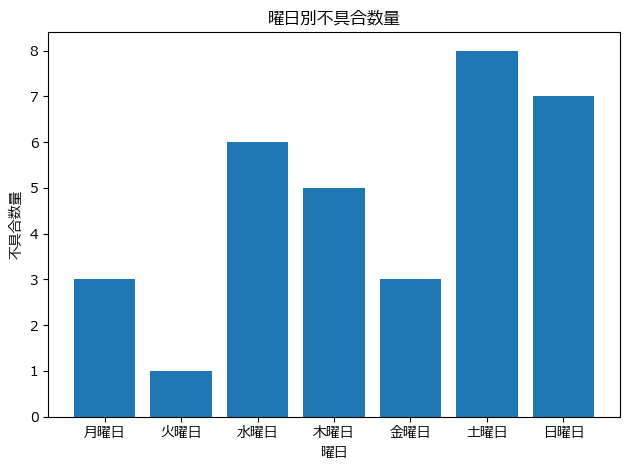

In [40]:
plt.bar(
    df_weekday_summary["occ_weekday"],
    df_weekday_summary["defect_qty_sum"],
)
plt.title("曜日別不具合数量")
plt.xlabel("曜日")
plt.ylabel("不具合数量")
plt.tight_layout()
plt.show()

In [41]:
plt.figure(figsize=(7, 4))

<Figure size 700x400 with 0 Axes>

<Figure size 700x400 with 0 Axes>

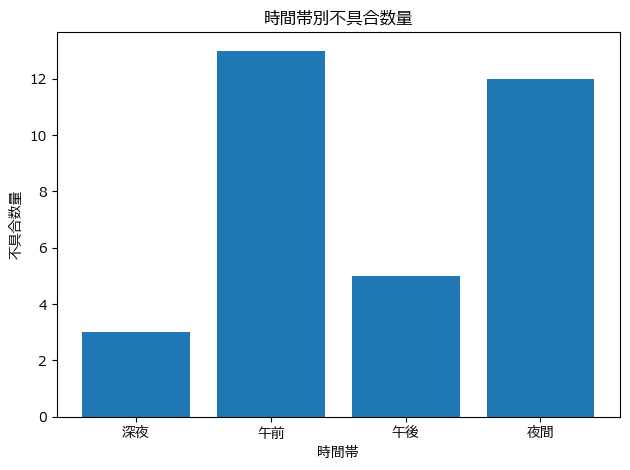

In [45]:
plt.bar(
    df_time_zone_summary["occ_time_zone"],
    df_time_zone_summary["defect_qty_sum"],
)

plt.title("時間帯別不具合数量")
plt.xlabel("時間帯")
plt.ylabel("不具合数量")

plt.tight_layout()
plt.show()